In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path    

In [159]:
# conecta a la base de datos mercado inmobiliario.db y carga la tabla tablon_analitico y cargala en un dataframe llamado df
import sqlite3

conn = sqlite3.connect('../datos/intermedios/analisis_inmobiliario.db')
df = pd.read_sql('SELECT * FROM tablon_analitico', conn)
conn.close()

In [160]:
df.head(5)

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,...,precio_noche_total,ingreso_anual,m2_estimado,coste_adquisicion,atractivo_turistico,beds_disc,bathrooms_disc,accommodates_disc,bedrooms_disc,margen_bruto
0,Apartamentos Dana Sol,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,365,NaN,2,...,157.0,1570.0,50.0,282150.0,77.342690,02_camas,<= 1_toilet,2,02_habs,0.56
1,Apartasol Apartamentos Dana,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,365,NaN,2,...,143.0,5720.0,50.0,282150.0,75.210312,03_camas,<= 1_toilet,2,03_habs,2.03
2,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Justicia,40.41884,-3.69655,Private room,65.0,1,365,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,...,65.0,15990.0,50.0,282150.0,75.768644,02_camas,1 - 2 toilets,4,02_habs,5.67
3,Adorable Apartment Malasaña-Gran Via,Universidad,40.42252,-3.70250,Entire home/apt,116.0,30,365,Beautiful apartment with spacious living room ...,2,...,116.0,6960.0,50.0,282150.0,75.339969,01_cama,<= 1_toilet,2,01_hab,2.47
4,"Heart of Malasaña Cozy, Quiet & Sunny Apartment",Universidad,40.42252,-3.70250,Entire home/apt,79.0,30,365,Cozy Apartment in great location in the center...,2,...,79.0,9480.0,50.0,282150.0,75.339969,02_camas,<= 1_toilet,2,02_habs,3.36


In [161]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13984 entries, 0 to 13983
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   name                       13984 non-null  str    
 1   neighbourhood              13984 non-null  str    
 2   latitude                   13984 non-null  float64
 3   longitude                  13984 non-null  float64
 4   room_type                  13984 non-null  str    
 5   precio_noche               13984 non-null  float64
 6   minimum_nights             13984 non-null  int64  
 7   availability_365           13984 non-null  int64  
 8   description                13610 non-null  str    
 9   accommodates               13984 non-null  int64  
 10  bathrooms                  13984 non-null  float64
 11  bedrooms                   13984 non-null  float64
 12  beds                       13984 non-null  float64
 13  review_scores_location     13984 non-null  float64
 14  e

In [162]:
df['precio_noche'].describe()

count    13984.000000
mean       128.686213
std         89.059862
min         20.000000
25%         74.000000
50%        110.000000
75%        157.000000
max       1000.000000
Name: precio_noche, dtype: float64

In [163]:
rango_precios = (df['precio_noche'].min(), df['precio_noche'].max())
rango_precios

(np.float64(20.0), np.float64(1000.0))

In [164]:
precio_mediana_distrito = df.groupby('distrito')['precio_noche'].median().sort_values(ascending=False)
precio_mediana_distrito

distrito
Salamanca                141.0
Centro                   128.0
Chamartín                121.0
Chamberí                 116.0
Retiro                   116.0
Tetuán                   107.0
Moncloa - Aravaca        102.0
Arganzuela                99.0
Hortaleza                 90.0
Ciudad Lineal             89.0
Barajas                   87.0
Fuencarral - El Pardo     84.0
Villa de Vallecas         77.0
San Blas - Canillejas     76.5
Villaverde                75.5
Puente de Vallecas        73.0
Carabanchel               70.0
Usera                     63.0
Latina                    60.0
Moratalaz                 60.0
Vicálvaro                 49.5
Name: precio_noche, dtype: float64

In [165]:
precio_mediana_barrio = df.groupby('neighbourhood')['precio_noche'].median().sort_values(ascending=False)
precio_mediana_barrio

neighbourhood
Recoletos      178.0
Castellana     172.0
Goya           154.5
Jerónimos      148.0
Sol            148.0
               ...  
Aguilas         39.0
Valdemarín      39.0
Amposta         38.0
Fontarrón       38.0
Los Angeles     33.0
Name: precio_noche, Length: 126, dtype: float64

In [166]:
factores_precio = df.corr(numeric_only=True)['precio_noche'].sort_values(ascending=False)
factores_precio

precio_noche                 1.000000
precio_noche_total           0.999378
accommodates                 0.554783
coste_adquisicion            0.545870
ingreso_anual                0.541155
m2_estimado                  0.466631
beds                         0.454596
bedrooms                     0.448627
bathrooms                    0.370847
margen_bruto                 0.306645
precio_m2                    0.304764
atractivo_turistico          0.277873
review_scores_location       0.124968
latitude                     0.051476
longitude                   -0.066669
estimated_occupancy_l365d   -0.068836
minimum_nights              -0.077181
availability_365                  NaN
Name: precio_noche, dtype: float64

In [167]:
competencia_barrio = df.groupby('neighbourhood').size()
competencia_barrio

neighbourhood
Abrantes         27
Acacias         124
Adelfas          77
Aeropuerto        7
Aguilas          26
               ... 
Valverde         75
Ventas          136
Vinateros        11
Vista Alegre     68
Zofío            21
Length: 126, dtype: int64

In [168]:
precio_vs_competencia = df.groupby('neighbourhood').agg({'precio_noche':'median', 'name':'count'}).rename(columns={'name':'num_inmuebles'})
precio_vs_competencia

,precio_noche,num_inmuebles
neighbourhood,,
Abrantes,44.0,27
Acacias,98.0,124
Adelfas,125.0,77
Aeropuerto,40.0,7
Aguilas,39.0,26
...,...,...
Valverde,84.0,75
Ventas,85.5,136
Vinateros,48.0,11


In [169]:
precio_por_tipo = df.groupby('room_type')['precio_noche'].median()
precio_por_tipo

room_type
Entire home/apt    126.0
Private room        51.0
Shared room         29.0
Name: precio_noche, dtype: float64

In [170]:
ocupacion_mediana = df['estimated_occupancy_l365d'].median()
ocupacion_mediana

np.float64(120.0)

In [171]:
ocupacion_mediana_distrito = df.groupby('distrito')['estimated_occupancy_l365d'].median().sort_values(ascending=False)
ocupacion_mediana_distrito

distrito
Barajas                  234.0
Arganzuela               144.0
Centro                   144.0
Villa de Vallecas        123.0
Ciudad Lineal            120.0
Retiro                   114.0
Carabanchel              114.0
Salamanca                114.0
Moratalaz                112.0
Moncloa - Aravaca        112.0
Chamberí                 108.0
San Blas - Canillejas    106.0
Latina                    93.0
Chamartín                 90.0
Puente de Vallecas        90.0
Tetuán                    84.0
Usera                     84.0
Vicálvaro                 78.0
Hortaleza                 72.0
Fuencarral - El Pardo     72.0
Villaverde                66.0
Name: estimated_occupancy_l365d, dtype: float64

In [172]:
ocupacion_mediana_barrio = df.groupby('neighbourhood')['estimated_occupancy_l365d'].median().sort_values(ascending=False)
ocupacion_mediana_barrio

neighbourhood
Alameda de Osuna    255.0
Corralejos          255.0
Santa Eugenia       255.0
Timón               249.0
Quintana            198.0
                    ...  
San Andrés           48.0
Nueva España         42.0
Amposta              40.0
Butarque             30.0
Palomas              24.0
Name: estimated_occupancy_l365d, Length: 126, dtype: float64

In [173]:
prob_ocupacion_distrito = df.groupby(['distrito', 'estimated_occupancy_l365d']).size().groupby(level=0).apply(lambda x: x / x.sum())
prob_ocupacion_distrito

distrito    distrito    estimated_occupancy_l365d
Arganzuela  Arganzuela  6                            0.030513
                        8                            0.002774
                        10                           0.001387
                        12                           0.040222
                        14                           0.004161
                                                       ...   
Villaverde  Villaverde  204                          0.017544
                        208                          0.008772
                        240                          0.017544
                        246                          0.008772
                        255                          0.061404
Length: 1213, dtype: float64

Analisis de Minicubo

In [174]:
df.columns

Index(['name', 'neighbourhood', 'latitude', 'longitude', 'room_type',
       'precio_noche', 'minimum_nights', 'availability_365', 'description',
       'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'review_scores_location', 'estimated_occupancy_l365d', 'precio_m2',
       'distrito', 'precio_noche_total', 'ingreso_anual', 'm2_estimado',
       'coste_adquisicion', 'atractivo_turistico', 'beds_disc',
       'bathrooms_disc', 'accommodates_disc', 'bedrooms_disc', 'margen_bruto'],
      dtype='str')

In [175]:
dimensiones = ['distrito', 'neighbourhood', 'room_type', 'bedrooms_disc', 'accommodates_disc', 'beds_disc']

metricas = ['precio_noche_total', 'estimated_occupancy_l365d', 'ingreso_anual', 'coste_adquisicion', 'margen_bruto']

In [176]:
minicubo = df[dimensiones + metricas]
minicubo

,distrito,neighbourhood,room_type,bedrooms_disc,accommodates_disc,beds_disc,precio_noche_total,estimated_occupancy_l365d,ingreso_anual,coste_adquisicion,margen_bruto
0,Centro,Sol,Entire home/apt,02_habs,2,02_camas,157.0,10,1570.0,282150.0,0.56
1,Centro,Universidad,Entire home/apt,03_habs,2,03_camas,143.0,40,5720.0,282150.0,2.03
2,Centro,Justicia,Private room,02_habs,4,02_camas,65.0,246,15990.0,282150.0,5.67
3,Centro,Universidad,Entire home/apt,01_hab,2,01_cama,116.0,60,6960.0,282150.0,2.47
4,Centro,Universidad,Entire home/apt,02_habs,2,02_camas,79.0,120,9480.0,282150.0,3.36
...,...,...,...,...,...,...,...,...,...,...,...
13979,Tetuán,Almenara,Private room,01_hab,2,01_cama,62.0,12,744.0,224250.0,0.33
13980,Centro,Palacio,Entire home/apt,01_hab,2,01_cama,194.0,32,6208.0,282150.0,2.20
13981,Puente de Vallecas,San Diego,Entire home/apt,04_habs,> 5,04_camas,154.0,6,924.0,161070.0,0.57
13982,Hortaleza,Apostol Santiago,Private room,01_hab,2,01_cama,34.0,6,204.0,199537.5,0.10


In [177]:
# Paso 2: Pasar a transaccional las dimensiones
minicubo_melt = minicubo.melt(id_vars=metricas, value_vars=dimensiones, var_name='dimension', value_name='valor')
minicubo_melt

,precio_noche_total,estimated_occupancy_l365d,ingreso_anual,coste_adquisicion,margen_bruto,dimension,valor
0,157.0,10,1570.0,282150.0,0.56,distrito,Centro
1,143.0,40,5720.0,282150.0,2.03,distrito,Centro
2,65.0,246,15990.0,282150.0,5.67,distrito,Centro
3,116.0,60,6960.0,282150.0,2.47,distrito,Centro
4,79.0,120,9480.0,282150.0,3.36,distrito,Centro
...,...,...,...,...,...,...,...
83899,62.0,12,744.0,224250.0,0.33,beds_disc,01_cama
83900,194.0,32,6208.0,282150.0,2.20,beds_disc,01_cama
83901,154.0,6,924.0,161070.0,0.57,beds_disc,04_camas
83902,34.0,6,204.0,199537.5,0.10,beds_disc,01_cama


In [181]:
# Paso 3: Agregar las métricas por "dimension" y "valor" con funciones deseadas (conteo y mediana)
minicubo_agg = minicubo_melt.groupby(['dimension', 'valor']).agg(
    mediana_precio_noche_total=('precio_noche_total', 'median'),
    mediana_ocupacion=('estimated_occupancy_l365d', 'median'),
    mediana_ingreso_anual=('ingreso_anual', 'median'),
    mediana_coste_adquisicion=('coste_adquisicion', 'median'),
    mediana_margen_bruto=('margen_bruto', 'median')
).reset_index()
minicubo_agg

,dimension,valor,mediana_precio_noche_total,mediana_ocupacion,mediana_ingreso_anual,mediana_coste_adquisicion,mediana_margen_bruto
0,accommodates_disc,1,41.0,93.0,3855.0,233625.00,1.865
1,accommodates_disc,2,88.0,120.0,9120.0,282150.00,4.020
2,accommodates_disc,3,109.0,126.0,13098.0,282150.00,5.060
3,accommodates_disc,4,129.0,120.0,15288.0,282150.00,5.745
4,accommodates_disc,> 5,185.0,132.0,23664.0,366795.00,5.890
...,...,...,...,...,...,...,...
160,neighbourhood,Vista Alegre,71.5,117.0,6864.0,137100.00,5.180
161,neighbourhood,Zofío,65.0,54.0,3510.0,132112.50,2.830
162,room_type,Entire home/apt,126.0,126.0,15861.0,282150.00,5.710
163,room_type,Private room,52.0,96.0,5100.0,236118.75,2.340


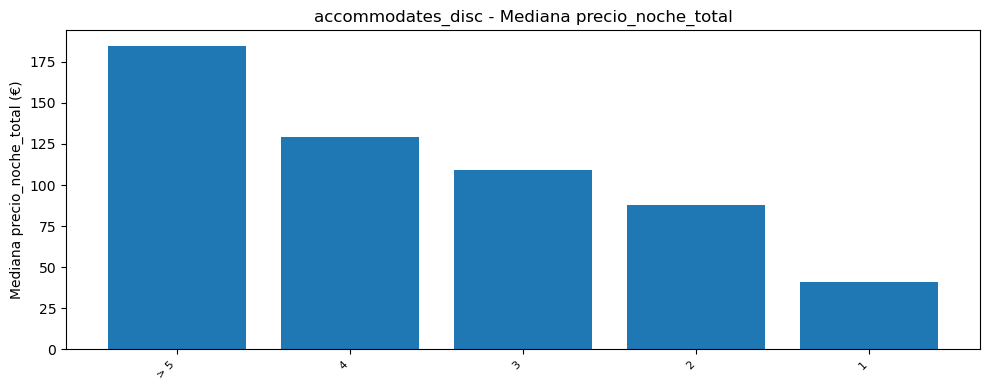

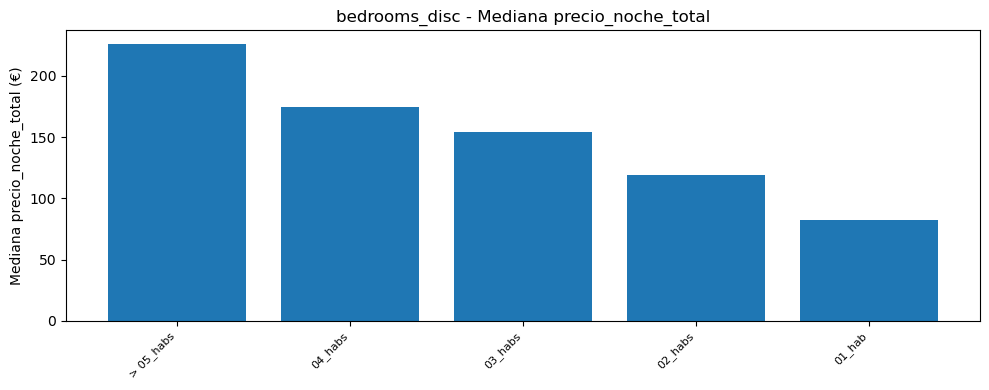

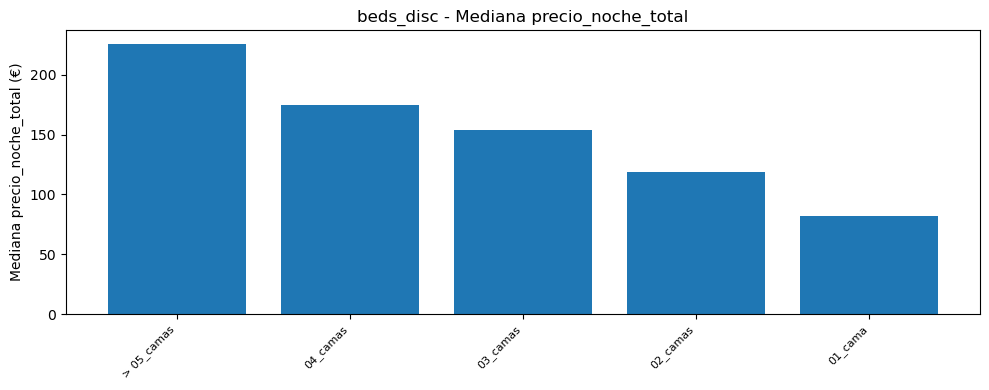

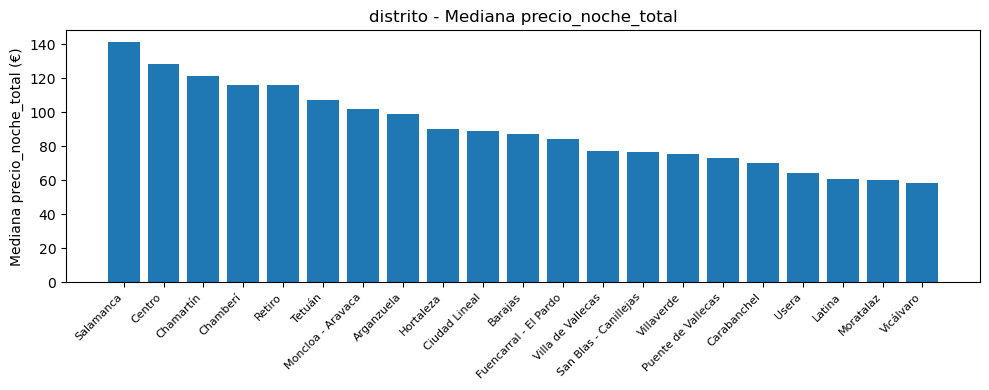

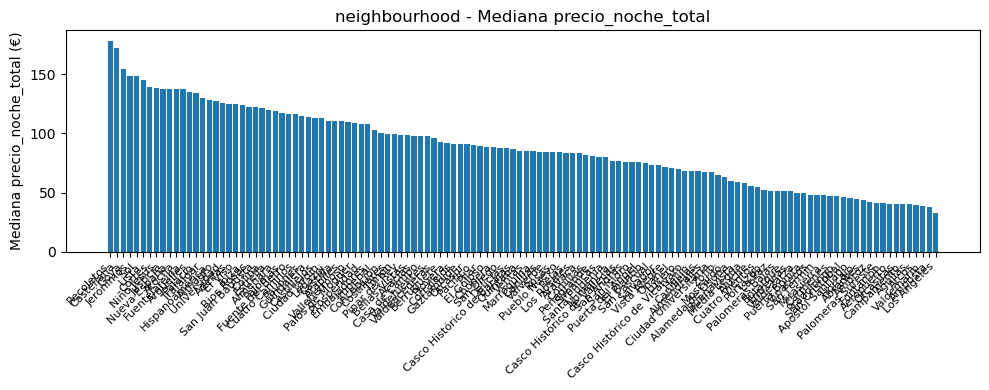

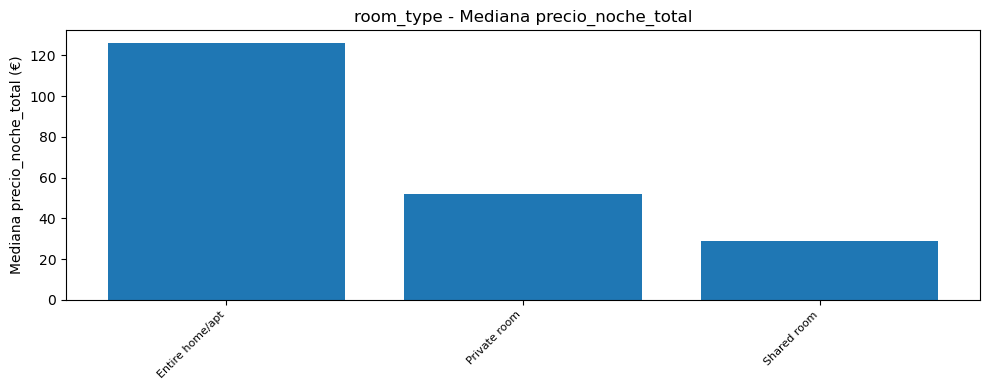

In [179]:
# Filtramos solo la métrica de interés
metrica = 'mediana_precio_noche_total'

# Obtenemos las dimensiones únicas
dimensiones_unicas = minicubo_agg['dimension'].unique()

for dimension in dimensiones_unicas:
    datos = minicubo_agg[minicubo_agg['dimension'] == dimension].sort_values(metrica, ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(datos['valor'].astype(str), datos[metrica])
    plt.title(f"{dimension} - Mediana precio_noche_total")
    plt.ylabel("Mediana precio_noche_total (€)")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

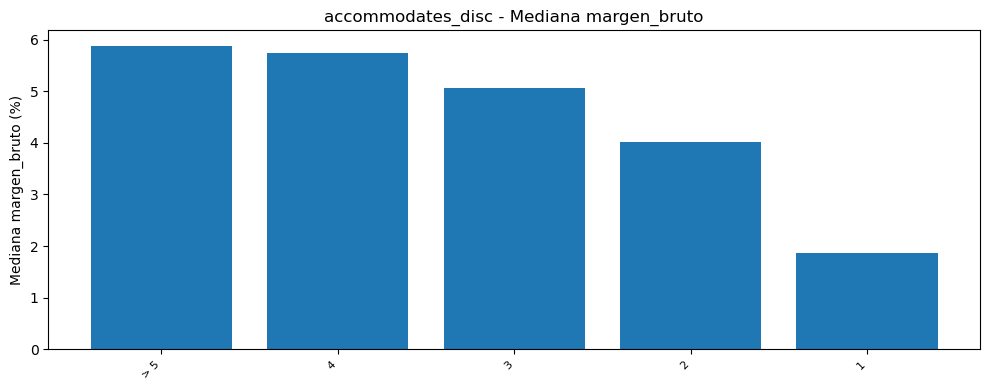

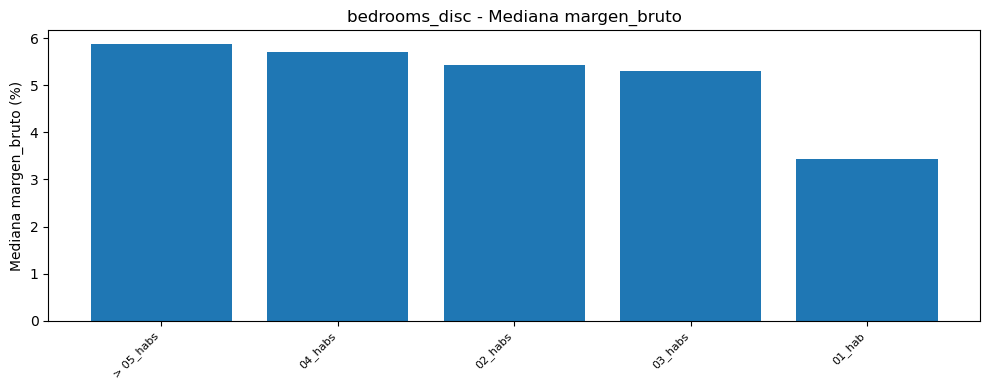

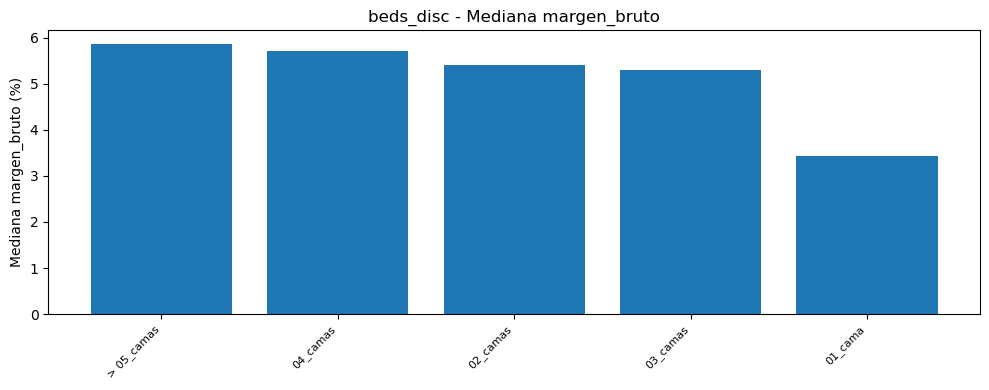

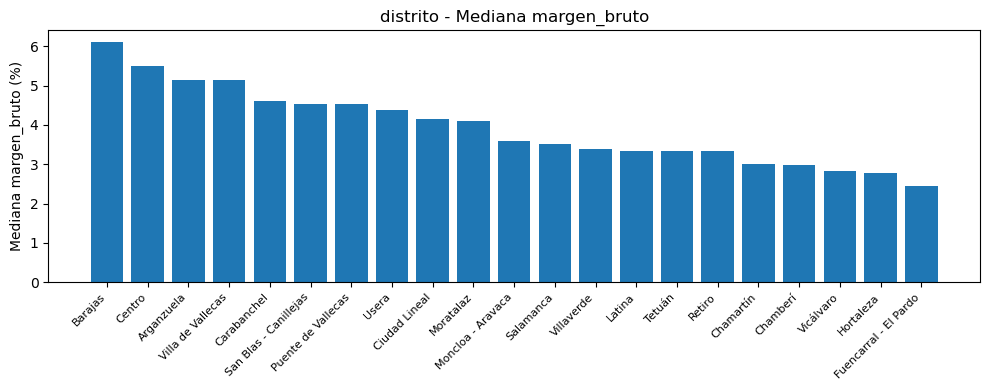

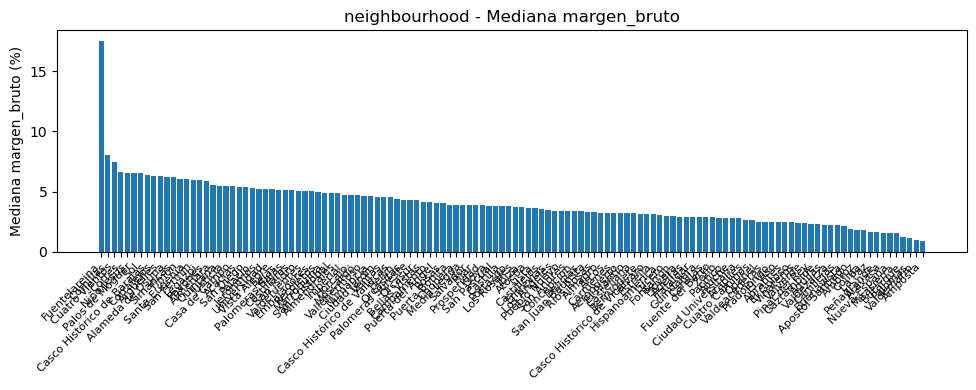

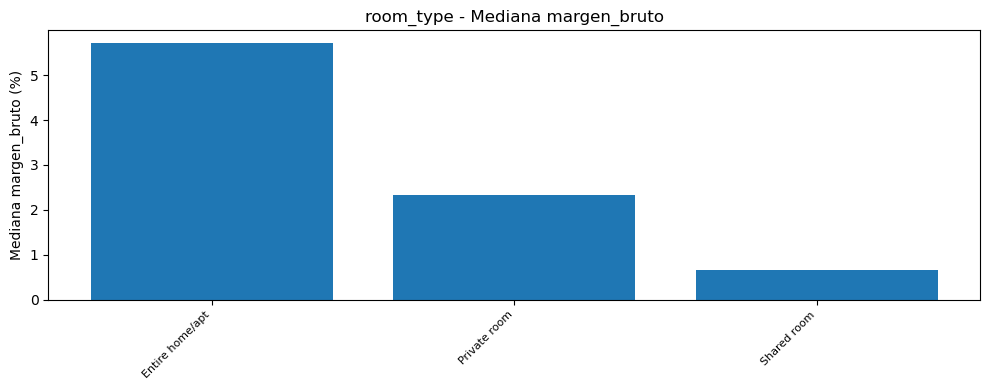

In [183]:
metrica = 'mediana_margen_bruto'
dimensiones_unicas = minicubo_agg['dimension'].unique()

for dimension in dimensiones_unicas:
    datos = minicubo_agg[minicubo_agg['dimension'] == dimension].sort_values(metrica, ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(datos['valor'].astype(str), datos[metrica])
    plt.title(f"{dimension} - Mediana margen_bruto")
    plt.ylabel("Mediana margen_bruto (%)")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
# Ver todos los registros de una zona concreta (ejemplo: 'Sol')
columna_filtro = 'neighbourhood'   # Cambia a 'distrito' si quieres filtrar por distrito
valor_filtro = 'Sol'

zona_data = df[df[columna_filtro] == valor_filtro]
zona_data

,dimension,valor,mediana_precio_noche_total,mediana_ocupacion,mediana_ingreso_anual,mediana_coste_adquisicion,mediana_margen_bruto
89,neighbourhood,Fuentelareina,137.0,180.0,24660.0,140936.25,17.5


In [192]:
# Nombres de los neighbourhoods
neighbourhoods = df['neighbourhood'].value_counts()
neighbourhoods

neighbourhood
Embajadores       1554
Universidad       1316
Palacio           1115
Sol                850
Justicia           706
                  ... 
Palomas              3
Fuentelareina        3
Cuatro Vientos       2
Horcajo              2
Valdemarín           1
Name: count, Length: 126, dtype: int64